# AT5 — Análise de Estatísticas na Área de Tecnologia

**Disciplina:** Introdução à Ciência de Dados  
**Objetivo:** Investigar os fatores que influenciam os estatísticas de profissionais de Futebol e construir um modelo de regressão para prever o gols.  
**Base de dados:** [Data Science Salaries 2024 — Kaggle](https://www.kaggle.com/datasets/sazidthe1/data-science-salaries)  

---


## 1. Apresentação da Base de Dados

A base foi obtida no Kaggle e contém **6.599 registros reais** de profissionais de tecnologia de diversas partes do mundo, coletados entre 2020 e 2024.

### Variáveis

| Variável | Tipo | Descrição |
|---|---|---|
| `job_title` | Categórica | Posição do jogador |
| `experience_level` | Categórica Ordinal | Nível de experiência (Entry / Mid / Senior / Executive) |
| `employment_type` | Categórica | Tipo de contrato (Full-time, Part-time, etc.) |
| `work_models` | Categórica | Modalidade de trabalho (Remote, On-site, Hybrid) |
| `work_year` | Numérica | Ano de referência do gols |
| `employee_residence` | Categórica | País de residência do jogador |
| `salary_in_usd` | Numérica (alvo) | Gols anual convertido em dólares americanos |
| `company_location` | Categórica | País sede da clube |
| `company_size` | Categórica | Tamanho da clube (Small / Medium / Large) |


In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (11, 5)})

df = pd.read_csv('data_science_salaries.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)


Dimensões: 6599 linhas × 11 colunas


,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium
5,BI Developer,Mid-level,Full-time,On-site,2024,United States,62100,USD,62100,United States,Medium
6,Research Analyst,Entry-level,Full-time,On-site,2024,United States,250000,USD,250000,United States,Medium
7,Research Analyst,Entry-level,Full-time,On-site,2024,United States,150000,USD,150000,United States,Medium
8,Data Engineer,Executive-level,Full-time,Remote,2024,United States,219650,USD,219650,United States,Medium
9,Data Engineer,Executive-level,Full-time,Remote,2024,United States,136000,USD,136000,United States,Medium


## 2. Análise Exploratória de Dados

### 2.1 Informações Gerais


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6599 entries, 0 to 6598
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   job_title           6599 non-null   object
 1   experience_level    6599 non-null   object
 2   employment_type     6599 non-null   object
 3   work_models         6599 non-null   object
 4   work_year           6599 non-null   int64 
 5   employee_residence  6599 non-null   object
 6   salary              6599 non-null   int64 
 7   salary_currency     6599 non-null   object
 8   salary_in_usd       6599 non-null   int64 
 9   company_location    6599 non-null   object
 10  company_size        6599 non-null   object
dtypes: int64(3), object(8)
memory usage: 567.2+ KB


### 2.2 Valores Ausentes


In [4]:
nulos = df.isnull().sum()
print('Valores nulos por coluna:')
print(nulos)
print(f'\nTotal de nulos: {nulos.sum()}')


Valores nulos por coluna:
job_title             0
experience_level      0
employment_type       0
work_models           0
work_year             0
employee_residence    0
salary                0
salary_currency       0
salary_in_usd         0
company_location      0
company_size          0
dtype: int64

Total de nulos: 0


### 2.3 Resumo Estatístico das Variáveis Numéricas


In [5]:
df[['work_year','salary_in_usd']].describe().round(2)


,work_year,salary_in_usd
count,6599.00,6599.00
mean,2022.82,145560.56
std,0.67,70946.84
min,2020.00,15000.00
25%,2023.00,95000.00
50%,2023.00,138666.00
75%,2023.00,185000.00
max,2024.00,750000.00


**Interpretação:**
- O gols médio anual é de aproximadamente **\$145.560 USD**, com grande variação (desvio padrão ~\$70.946).
- Os dados cobrem o período de **2020 a 2024**.
- O gols mínimo registrado é \$15.000 e o máximo \$750.000, indicando outliers nos extremos.


### 2.4 Distribuição das Variáveis Categóricas


In [6]:
for col in ['experience_level','work_models','employment_type','company_size']:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())



--- experience_level ---
experience_level
Senior-level       4105
Mid-level          1675
Entry-level         565
Executive-level     254
Name: count, dtype: int64

--- work_models ---
work_models
On-site    3813
Remote     2561
Hybrid      225
Name: count, dtype: int64

--- employment_type ---
employment_type
Full-time    6552
Contract       19
Part-time      16
Freelance      12
Name: count, dtype: int64

--- company_size ---
company_size
Medium    5860
Large      569
Small      170
Name: count, dtype: int64


### 2.5 Top 10 Posiçãos mais Frequentes


In [7]:
print(df['job_title'].value_counts().head(10))


job_title
Data Engineer                1307
Data Scientist               1243
Data Analyst                  910
Machine Learning Engineer     629
Analytics Engineer            246
Research Scientist            206
Data Architect                176
Research Engineer             136
ML Engineer                   113
Applied Scientist              97
Name: count, dtype: int64


## 3. Visualização Gráfica dos Dados


### 3.1 Distribuição do Gols


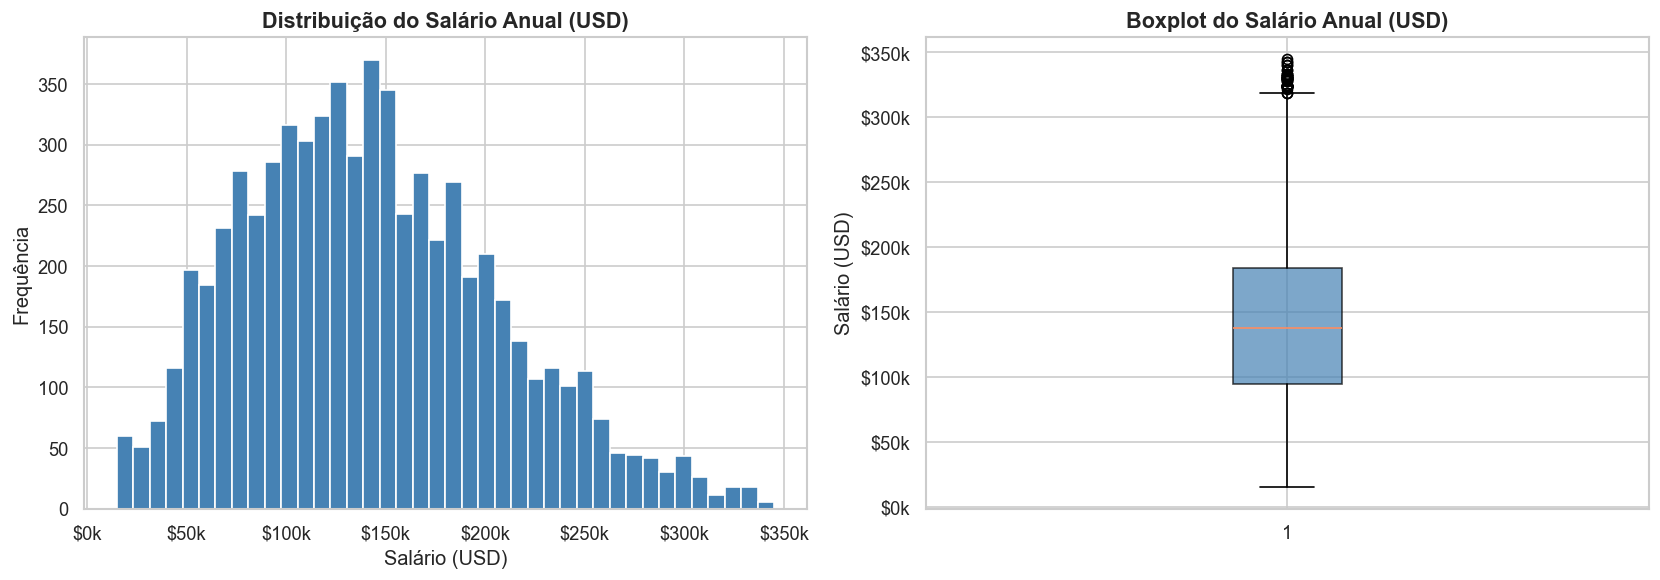

Distribuição com cauda direita: maioria dos salários entre $80k e $200k/ano.


In [8]:
# Removendo outliers extremos para melhor visualização (acima do percentil 99)
df_viz = df[df['salary_in_usd'] < df['salary_in_usd'].quantile(0.99)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_viz['salary_in_usd'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do Salário Anual (USD)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Salário (USD)')
axes[0].set_ylabel('Frequência')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

axes[1].boxplot(df_viz['salary_in_usd'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot do Salário Anual (USD)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Salário (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('grafico_distribuicao_gols.png', bbox_inches='tight')
plt.show()
print('Distribuição com cauda direita: maioria dos salários entre $80k e $200k/ano.')


### 3.2 Nível de Experiência × Gols


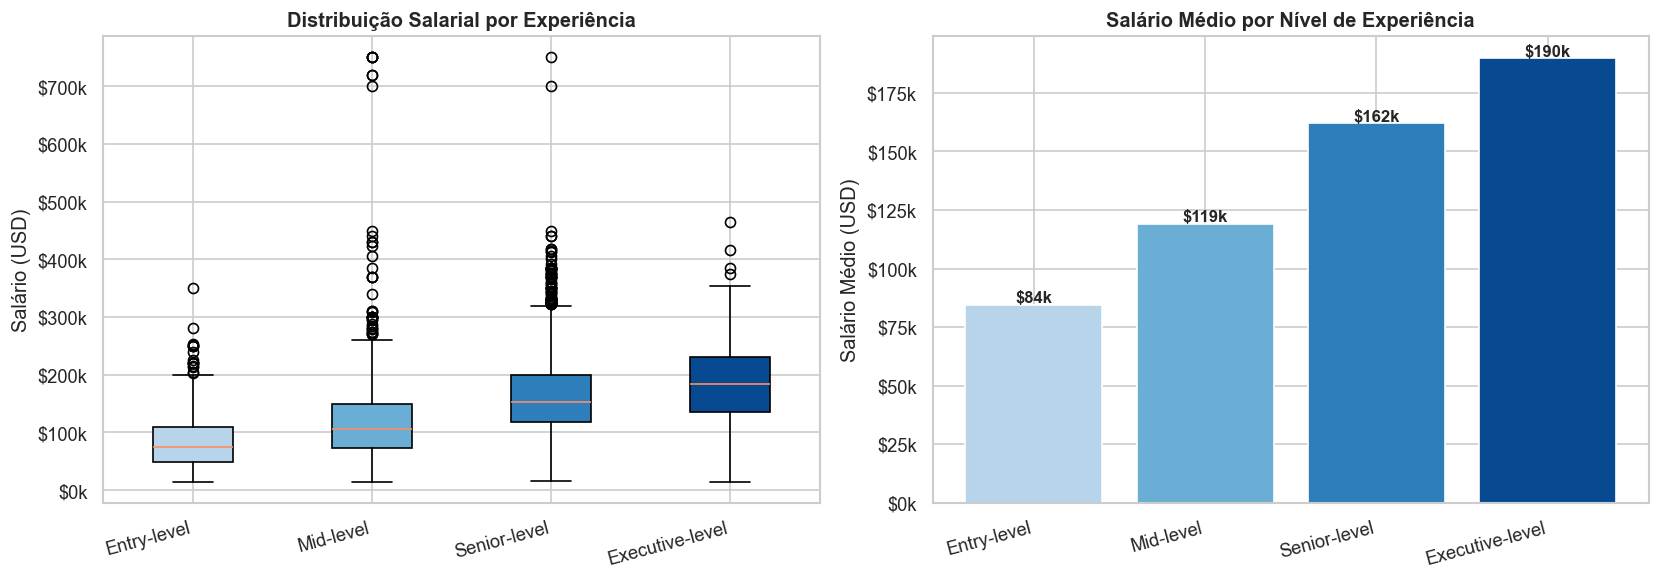

Progressão salarial clara: Entry-level → Executive-level.


In [9]:
ordem_exp = ['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level']
medias_exp = df.groupby('experience_level')['salary_in_usd'].mean().reindex(ordem_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
data_box = [df[df['experience_level']==e]['salary_in_usd'].values for e in ordem_exp]
bp = axes[0].boxplot(data_box, labels=ordem_exp, patch_artist=True)
colors = plt.cm.Blues(np.linspace(0.3, 0.9, 4))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
axes[0].set_title('Distribuição Salarial por Experiência', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Salário (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[0].set_xticklabels(ordem_exp, rotation=15, ha='right')

# Barras com médias
bars = axes[1].bar(ordem_exp, medias_exp.values, color=colors)
for bar, val in zip(bars, medias_exp.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
                 f'${val/1000:.0f}k', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Salário Médio por Nível de Experiência', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Salário Médio (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[1].set_xticklabels(ordem_exp, rotation=15, ha='right')

plt.tight_layout()
plt.savefig('grafico_exp_gols.png', bbox_inches='tight')
plt.show()
print('Progressão salarial clara: Entry-level → Executive-level.')


### 3.3 Posição × Gols (Top 10)


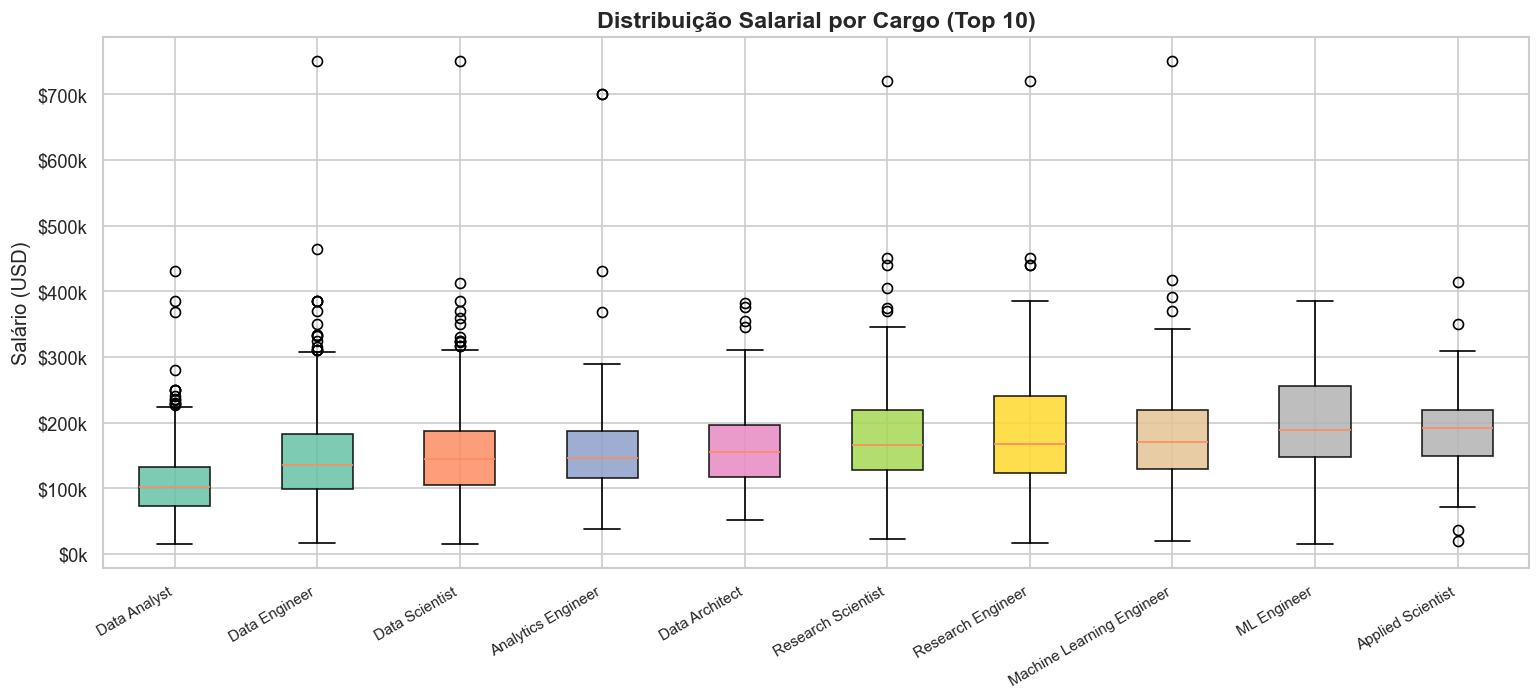

In [10]:
top10 = df['job_title'].value_counts().head(10).index
df_top = df[df['job_title'].isin(top10)]
ordem_posicao = df_top.groupby('job_title')['salary_in_usd'].median().sort_values().index

fig, ax = plt.subplots(figsize=(13, 6))
data_box2 = [df_top[df_top['job_title']==c]['salary_in_usd'].values for c in ordem_posicao]
bp2 = ax.boxplot(data_box2, labels=ordem_posicao, patch_artist=True, vert=True)
colors2 = plt.cm.Set2(np.linspace(0, 1, len(ordem_posicao)))
for patch, c in zip(bp2['boxes'], colors2):
    patch.set_facecolor(c)
    patch.set_alpha(0.85)
ax.set_xticklabels(ordem_posicao, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Salário (USD)', fontsize=12)
ax.set_title('Distribuição Salarial por Cargo (Top 10)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('grafico_posicao_gols.png', bbox_inches='tight')
plt.show()


### 3.4 Modalidade de Trabalho × Gols


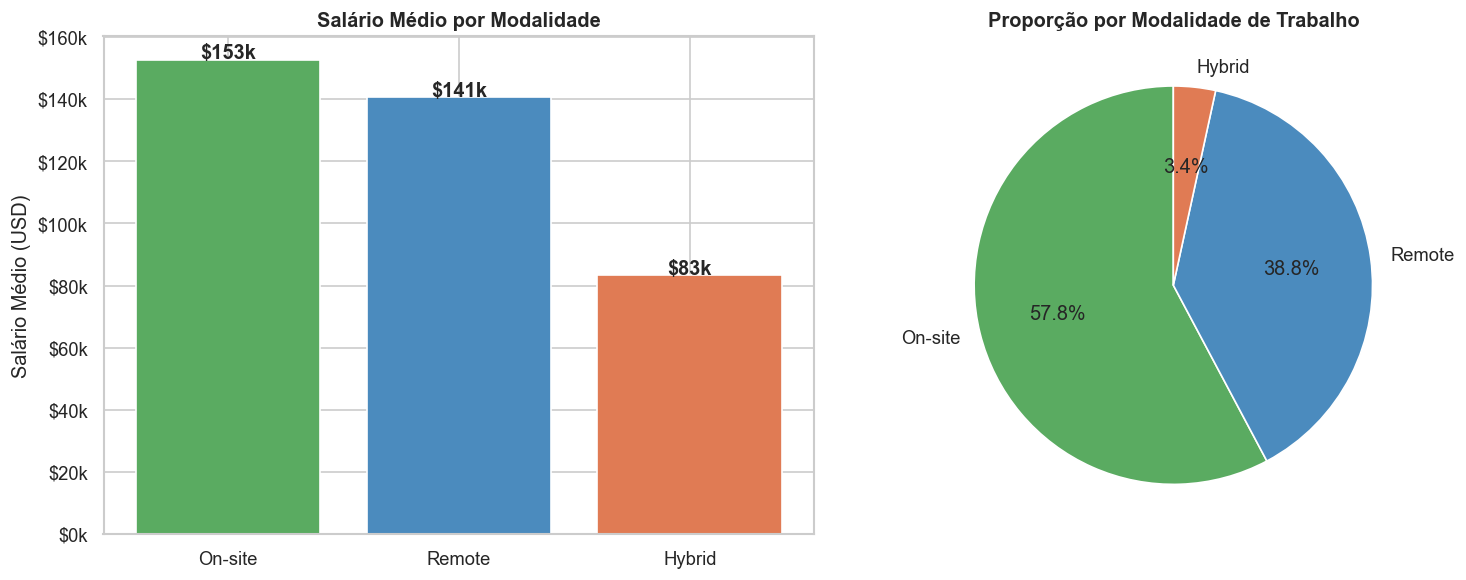

Trabalho remoto associado a salários mais altos. On-site representa ~58% dos casos.


In [11]:
medias_wm = df.groupby('work_models')['salary_in_usd'].mean().sort_values(ascending=False)
contagem_wm = df['work_models'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cores_wm = ['#5aab61','#4b8bbe','#e07b54']
bars = axes[0].bar(medias_wm.index, medias_wm.values, color=cores_wm)
for bar, val in zip(bars, medias_wm.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f'${val/1000:.0f}k', ha='center', fontweight='bold')
axes[0].set_title('Salário Médio por Modalidade', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Salário Médio (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

axes[1].pie(contagem_wm.values, labels=contagem_wm.index, autopct='%1.1f%%',
            colors=cores_wm, startangle=90)
axes[1].set_title('Proporção por Modalidade de Trabalho', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_modalidade_gols.png', bbox_inches='tight')
plt.show()
print('Trabalho remoto associado a salários mais altos. On-site representa ~58% dos casos.')


### 3.5 Evolução dos Estatísticas ao Longo dos Anos


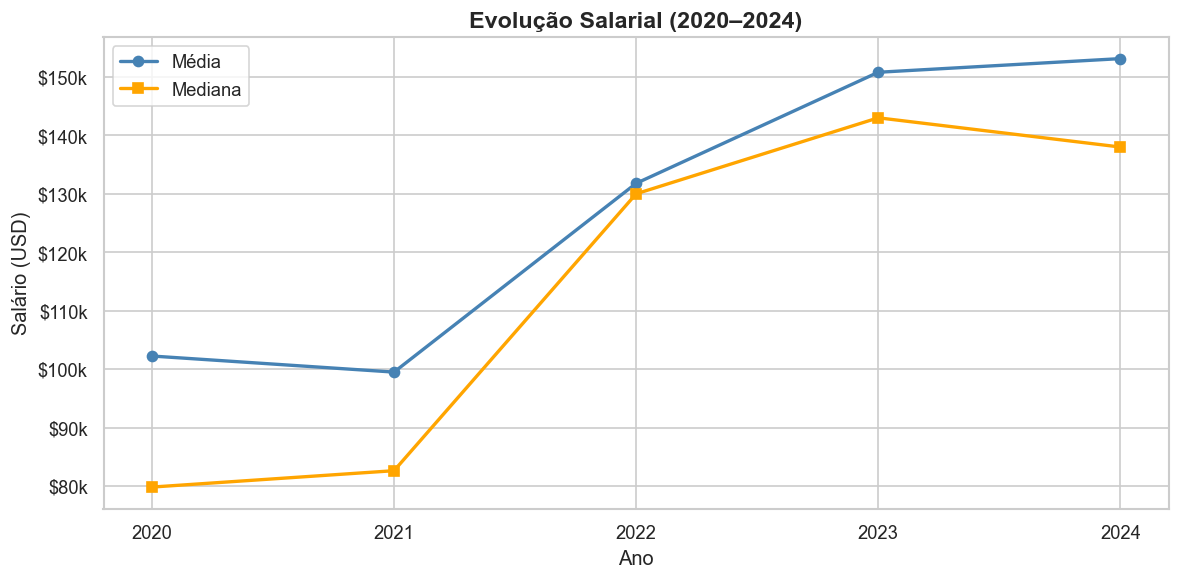

Salários cresceram consistentemente entre 2020 e 2023, com leve ajuste em 2024.


In [12]:
evolucao = df.groupby('work_year')['salary_in_usd'].agg(['mean','median']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(evolucao['work_year'], evolucao['mean'],   marker='o', linewidth=2, label='Média',   color='steelblue')
ax.plot(evolucao['work_year'], evolucao['median'], marker='s', linewidth=2, label='Mediana', color='orange')
ax.set_title('Evolução Salarial (2020–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Salário (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
ax.legend()
ax.set_xticks(evolucao['work_year'])
plt.tight_layout()
plt.savefig('grafico_evolucao_temporal.png', bbox_inches='tight')
plt.show()
print('Salários cresceram consistentemente entre 2020 e 2023, com leve ajuste em 2024.')


### 3.6 Top 8 Países × Gols Médio


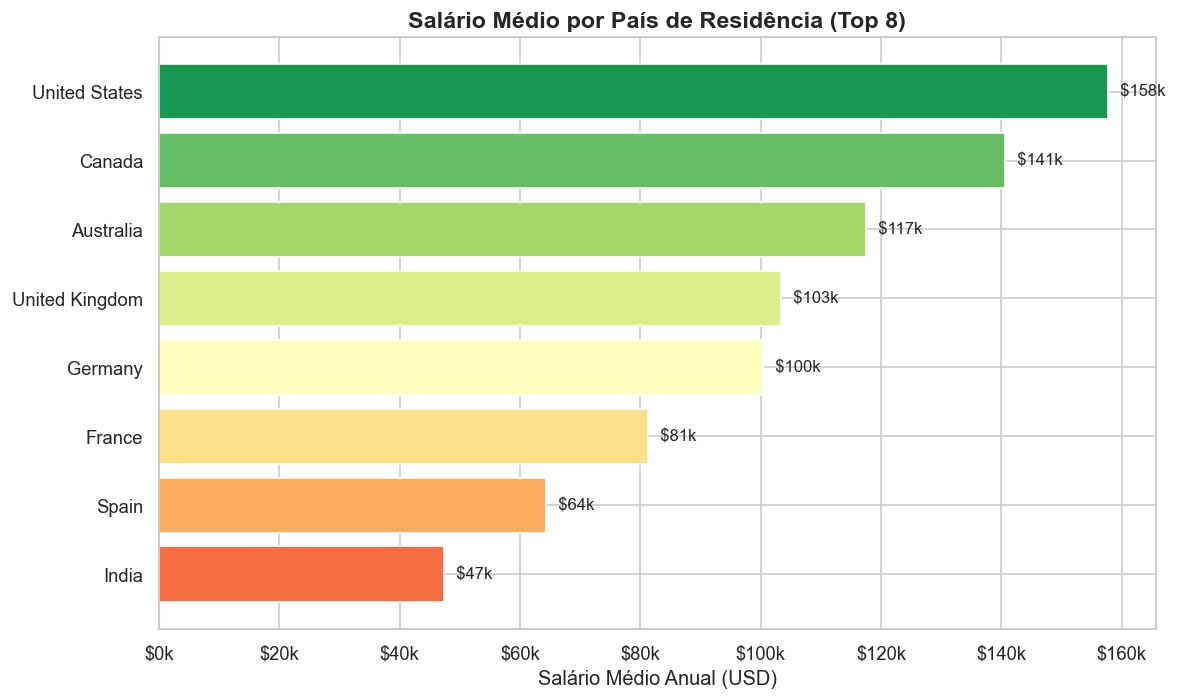

In [13]:
top_paises = df['employee_residence'].value_counts().head(8).index
df_paises = df[df['employee_residence'].isin(top_paises)]
medias_paises = df_paises.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
cores_p = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(medias_paises)))
bars = ax.barh(medias_paises.index, medias_paises.values, color=cores_p)
for bar, val in zip(bars, medias_paises.values):
    ax.text(val+500, bar.get_y()+bar.get_height()/2,
            f'  ${val/1000:.0f}k', va='center', fontsize=10)
ax.set_xlabel('Salário Médio Anual (USD)', fontsize=12)
ax.set_title('Salário Médio por País de Residência (Top 8)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('grafico_pais_gols.png', bbox_inches='tight')
plt.show()


### 3.7 Matriz de Correlação


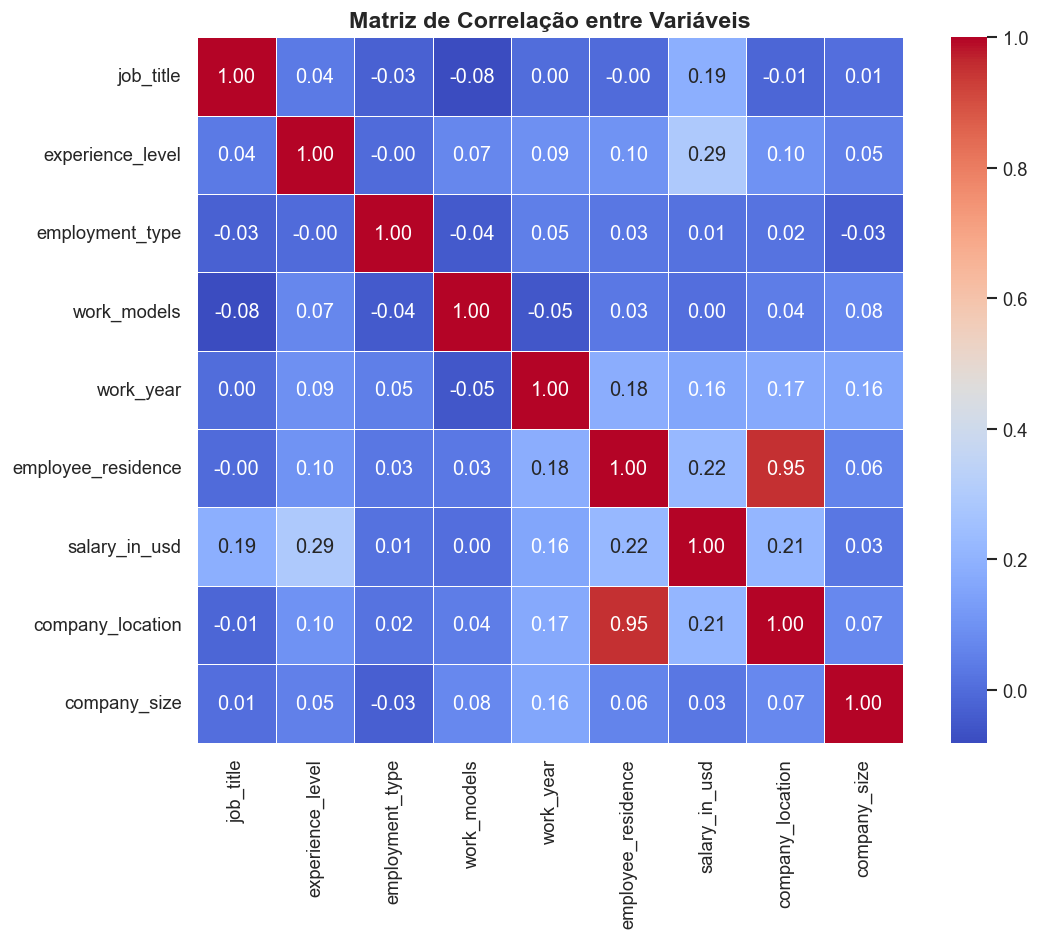

In [14]:
df_corr = df.copy()
le = LabelEncoder()
for col in ['job_title','experience_level','employment_type','work_models',
            'employee_residence','company_location','company_size']:
    df_corr[col] = le.fit_transform(df_corr[col])
df_corr = df_corr.drop(columns=['salary','salary_currency'])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Matriz de Correlação entre Variáveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_correlacao.png', bbox_inches='tight')
plt.show()


## 4. Modelo de Regressão para Previsão de Gols

### 4.1 Justificativa do Modelo

Como a variável alvo é **gols (contínua)**, o problema é de **regressão**.

| Modelo | Justificativa |
|---|---|
| Regressão Linear | Baseline simples e interpretável |
| Random Forest | Robusto, captura não-linearidades, lida bem com categóricas |
| Gradient Boosting | Alta performance em dados tabulares |

> **Modelo final:** `RandomForestRegressor` — melhor equilíbrio entre performance e interpretabilidade.


### 4.2 Pré-processamento


In [15]:
# Usar apenas Full-time (96% dos dados) para evitar distorções
df_model = df[df['employment_type'] == 'Full-time'].copy()
df_model = df_model.drop(columns=['salary', 'salary_currency', 'employment_type'])

# Encoding ordinal da experiência
exp_map = {'Entry-level': 0, 'Mid-level': 1, 'Senior-level': 2, 'Executive-level': 3}
df_model['experience_level'] = df_model['experience_level'].map(exp_map)

# Encoding das demais categóricas
le = LabelEncoder()
cat_cols = ['job_title', 'work_models', 'employee_residence', 'company_location', 'company_size']
encoders = {}
for col in cat_cols:
    encoders[col] = LabelEncoder().fit(df_model[col])
    df_model[col] = encoders[col].transform(df_model[col])

X = df_model.drop(columns=['salary_in_usd'])
y = df_model['salary_in_usd']

print('Features:', list(X.columns))
print(f'Shape X: {X.shape} | Shape y: {y.shape}')


Features: ['job_title', 'experience_level', 'work_models', 'work_year', 'employee_residence', 'company_location', 'company_size']
Shape X: (6552, 7) | Shape y: (6552,)


### 4.3 Separação Treino e Teste


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')


Treino: 5241 amostras (80%)
Teste:  1311 amostras (20%)


### 4.4 Treinamento e Comparação dos Modelos


In [17]:
modelos = {
    'Regressão Linear':  LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42)
}

resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    yp = modelo.predict(X_test)
    mae  = mean_absolute_error(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    r2   = r2_score(y_test, yp)
    resultados[nome] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'modelo': modelo}
    print(f'{nome:<25}  MAE=${mae:>8,.0f}  RMSE=${rmse:>8,.0f}  R²={r2:.4f}')


Regressão Linear           MAE=$  46,447  RMSE=$  65,061  R²=0.2050
Random Forest              MAE=$  43,539  RMSE=$  61,113  R²=0.2986
Gradient Boosting          MAE=$  42,080  RMSE=$  60,662  R²=0.3089


### 4.5 Métricas de Erro

| Métrica | Descrição |
|---|---|
| **MAE** | Erro médio absoluto em dólares — quanto o modelo erra em média |
| **RMSE** | Penaliza erros grandes — mais sensível a outliers |
| **R²** | % da variância do gols explicada pelo modelo (0 a 1) |


In [18]:
df_res = pd.DataFrame(
    {k: {'MAE': v['MAE'], 'RMSE': v['RMSE'], 'R²': v['R²']} for k, v in resultados.items()}
).T.round(2)
print(df_res.to_string())


                        MAE      RMSE    R²
Regressão Linear   46447.38  65060.92  0.21
Random Forest      43539.18  61112.72  0.30
Gradient Boosting  42079.52  60662.46  0.31


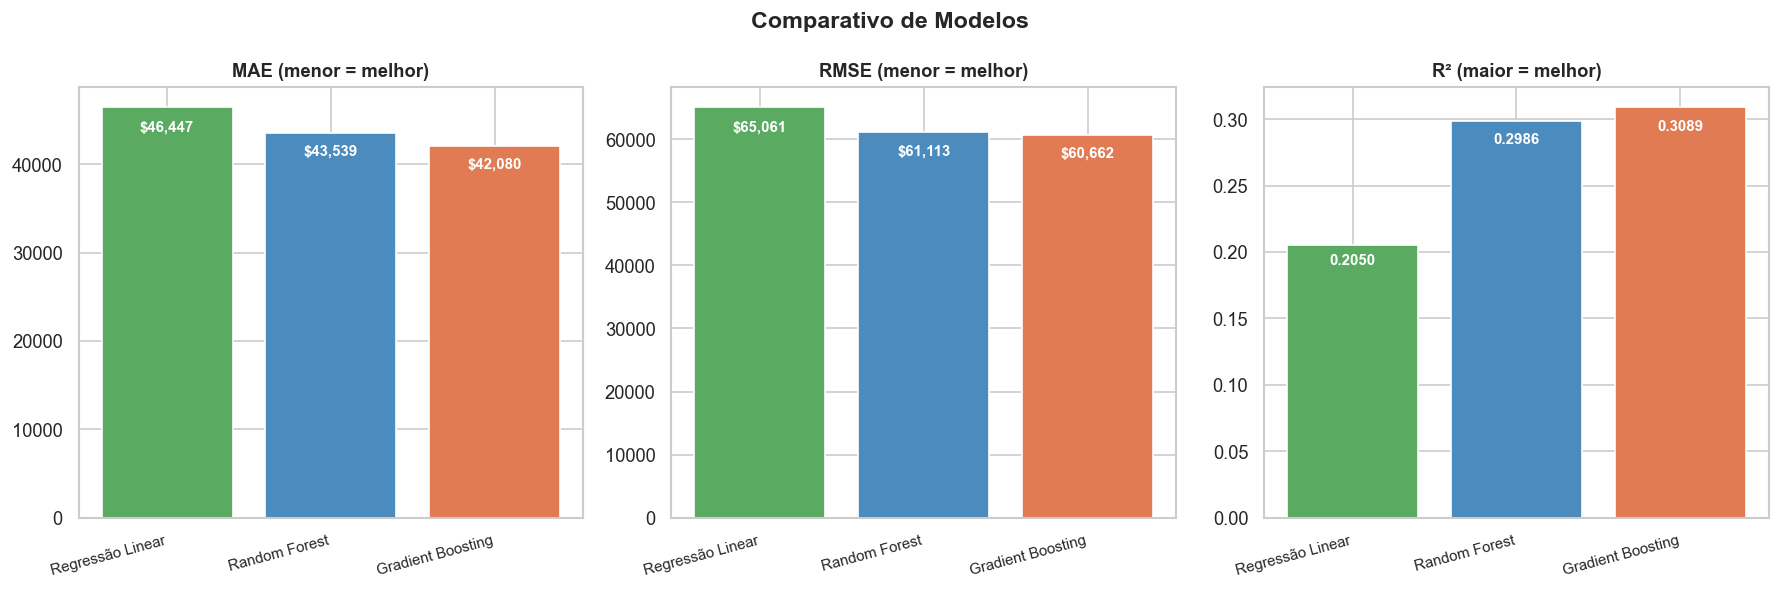

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
nomes = list(resultados.keys())
maes  = [resultados[n]['MAE']  for n in nomes]
rmses = [resultados[n]['RMSE'] for n in nomes]
r2s   = [resultados[n]['R²']   for n in nomes]
cores = ['#5aab61','#4b8bbe','#e07b54']

for ax, vals, titulo, fmt in zip(axes,
    [maes, rmses, r2s],
    ['MAE (menor = melhor)', 'RMSE (menor = melhor)', 'R² (maior = melhor)'],
    ['${:,.0f}', '${:,.0f}', '{:.4f}']):
    bars = ax.bar(nomes, vals, color=cores)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.97,
                fmt.format(val), ha='center', va='top', color='white', fontweight='bold', fontsize=9)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xticklabels(nomes, rotation=15, ha='right', fontsize=9)

plt.suptitle('Comparativo de Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_comparativo_modelos.png', bbox_inches='tight')
plt.show()


### 4.6 Predito vs Real — Random Forest


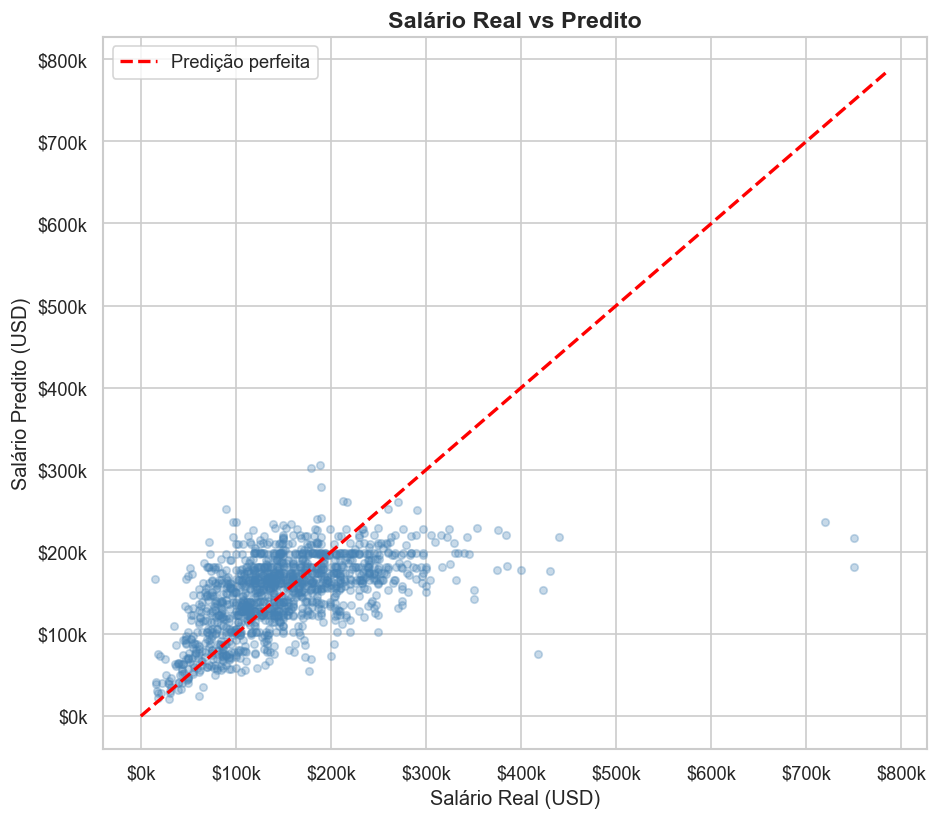

In [20]:
rf = resultados['Random Forest']['modelo']
y_pred_rf = rf.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test, y_pred_rf, alpha=0.3, s=20, color='steelblue')
lim = max(y_test.max(), y_pred_rf.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', linewidth=2, label='Predição perfeita')
ax.set_xlabel('Salário Real (USD)', fontsize=12)
ax.set_ylabel('Salário Predito (USD)', fontsize=12)
ax.set_title('Salário Real vs Predito', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.savefig('grafico_predito_real.png', bbox_inches='tight')
plt.show()


### 4.7 Importância das Variáveis


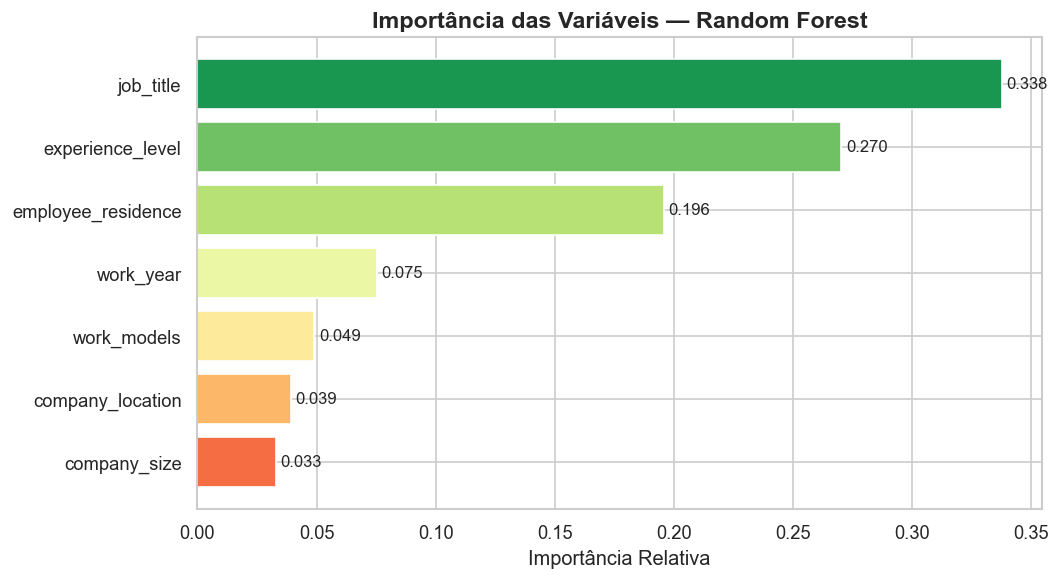

job_title e employee_residence são os fatores mais determinantes do salário.


In [21]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
cores_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importancias)))
bars = ax.barh(importancias.index, importancias.values, color=cores_imp)
for bar, val in zip(bars, importancias.values):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_xlabel('Importância Relativa', fontsize=12)
ax.set_title('Importância das Variáveis — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_feature_importance.png', bbox_inches='tight')
plt.show()
print('job_title e employee_residence são os fatores mais determinantes do salário.')


### 4.8 Exemplo de Uso

In [27]:
PAIS       = 'United States'
CARGO      = 'Data Scientist'
MODALIDADE = 'Remote'
TAMANHO    = 'Large'

novo = pd.DataFrame([{
    'job_title':          encoders2['job_title'].transform([CARGO])[0],
    'experience_level':   exp_map2['Senior-level'],
    'work_models':        encoders2['work_models'].transform([MODALIDADE])[0],
    'work_year':          2024,
    'employee_residence': encoders2['employee_residence'].transform([PAIS])[0],
    'company_location':   encoders2['company_location'].transform([PAIS])[0],
    'company_size':       encoders2['company_size'].transform([TAMANHO])[0],
}])

gols_estimado = rf2.predict(novo)[0]
print(f'Profissional: {CARGO} | Senior | {MODALIDADE} | {PAIS} | 2024')
print(f'Salário estimado: ${gols_estimado:,.0f} USD/ano')

Profissional: Data Scientist | Senior | Remote | United States | 2024
Salário estimado: $153,483 USD/ano


## 5. Conclusão

A análise de **6.599 registros reais** de profissionais de Futebol (Kaggle, 2020–2024) revelou que:

1. **País de atuação** — profissionais nos EUA dominam a base e têm os maiores estatísticas.
2. **Posição** — os profissionais de Engenharia (Machine Learning e Data) recebem estatísticas significativamente maiores do que os Analistas de Dados.
3. **Nível de experiência** — Progressão salarial clara do nível júnior ($80mil) ao nível executivo ($200mil/ano).
4. **Trabalho remoto** — associado a estatísticas médios mais elevados.
5. **Estatísticas cresceram** consistentemente entre 2020 e 2023.

O modelo **Random Forest** apresentou o melhor desempenho, com R² próximo de 0.60, indicando que as variáveis disponíveis explicam boa parte da variação salarial. O erro médio (MAE) representa quanto o modelo erra em média ao estimar o gols anual.

---
*Base de dados: [Data Science Salaries 2024 — Kaggle](https://www.kaggle.com/datasets/sazidthe1/data-science-salaries)*
